# 🌿 NDVI Vegetation Classification — Research Notebook

**Author:** *(your name)*  
**Institution:** *(your institution)*  
**Date:** *(YYYY-MM-DD)*  
**Dataset:** Single-image drone survey containing multispectral GeoTIFF bands

---

## Overview

This notebook performs a complete NDVI (Normalised Difference Vegetation Index)
classification workflow on multispectral drone imagery. Starting from raw
near-infrared (NIR) and red reflectance rasters, it:

1. Extracts full raster metadata and sensor geometry
2. Derives the Ground Sampling Distance (GSD) from the affine transform
3. Computes NDVI using the standard radiometric formula
4. Classifies every pixel into four ecologically-defined vegetation health classes
5. Calculates the real-world land area of each class using GSD-based pixel geometry
6. Produces a dedicated healthy land area report
7. Exports georeferenced outputs and publication-ready figures

### NDVI Classification Schema

| Class | NDVI Range | Vegetation Status | Typical Cover Types |
|-------|-----------|-------------------|---------------------|
| 1 | −1.0 → 0.0 | Non-vegetated | Water, snow, clouds, bare soil, rock, infrastructure |
| 2 | 0.0 → 0.2 | Sparse / bare | Extremely sparse vegetation, newly planted fields |
| 3 | 0.2 → 0.5 | Moderate | Shrubs, grasslands, senescing crops, stressed vegetation |
| 4 | 0.5 → 1.0 | Dense / healthy | Lush crops, temperate forests, rainforests |

---

### Required Input Files

| File | Description |
|------|-------------|
| `result_NIR.tif` | Near-infrared reflectance band (single-band GeoTIFF) |
| `result_Red.tif` | Red reflectance band (single-band GeoTIFF) |

Both files must share the same CRS, resolution, and spatial extent.

### Output Files Produced

| File | Description |
|------|-------------|
| `NDVI_computed.tif` | Computed NDVI raster (float32, georeferenced) |
| `ndvi_classified.tif` | Classified raster (uint8, class values 1–4, georeferenced) |
| `ndvi_classification_stats.csv` | Per-class pixel count, percentage, and area |
| `ndvi_healthy_area_summary.csv` | Aggregated healthy and vegetated area metrics |
| `ndvi_classification_report.png` | 4-panel publication figure |

---
## Section 1 — Environment Setup

Install and import all required libraries. `rasterio` is the only package not
pre-installed in Google Colab; all others (`numpy`, `pandas`, `matplotlib`) are
available by default.

In [ ]:
# ── 1.1  Install external dependencies ───────────────────────────────────────
# rasterio provides GDAL-backed reading/writing of GeoTIFF rasters, including
# access to the affine transform, CRS, and nodata metadata.
!pip install rasterio --quiet

print("✅ Environment ready")

✅ Environment ready


In [ ]:
# ── 1.2  Import standard and third-party libraries ───────────────────────────

import os           # file existence checks and path manipulation
import math         # trigonometric functions used in GSD degree-to-metre conversion
import numpy as np  # array operations; all raster data is handled as NumPy arrays
import pandas as pd # tabular statistics and CSV export

import matplotlib.pyplot as plt          # figure creation
import matplotlib.patches as mpatches   # legend patch handles for classified map
import matplotlib.colors as mcolors     # custom discrete colourmaps and normalisations

import rasterio                 # GeoTIFF I/O (read bands, CRS, transform, nodata)
from rasterio.crs import CRS    # CRS introspection (geographic vs projected check)

from IPython.display import display  # render styled pandas DataFrames in Colab

# Render all matplotlib figures inline within the notebook output cells
%matplotlib inline
plt.rcParams["figure.dpi"] = 120  # default figure resolution for inline display

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


---
## Section 2 — Data Ingestion

Upload the two source reflectance rasters: the **NIR band** (`result_NIR.tif`)
and the **Red band** (`result_Red.tif`). Both must originate from the same
drone survey flight so that pixel grids are co-registered.

> **Google Drive alternative:** If your files are already on Drive, skip the
> upload cell and uncomment the Drive mount block instead.

In [ ]:
# ── 2.1  Upload NIR and Red band GeoTIFFs from local disk ────────────────────
#
# The Colab files.upload() widget opens a browser file picker.
# Select BOTH files in a single upload session.
# The cell then auto-detects which uploaded filename corresponds to each band
# by searching for 'nir' or 'red' (case-insensitive) in the filename.

from google.colab import files

print("📂  Please upload result_NIR.tif and result_Red.tif ...")
uploaded = files.upload()  # opens the file picker; select both files

# Auto-detect band paths from uploaded filenames
# 'NIR' detection: filename contains 'nir' (any case)
nir_path = next(
    (k for k in uploaded if "nir" in k.lower()),
    None
)
# 'Red' detection: filename contains 'red' but NOT 'rededge' (to avoid confusion
# with the RedEdge band present in some multispectral sensor datasets)
red_path = next(
    (k for k in uploaded if "red" in k.lower() and "edge" not in k.lower()),
    None
)

# Validation: abort with a clear message if either band was not identified
if not nir_path or not red_path:
    print("\n⚠️  Auto-detection failed. Files received:", list(uploaded.keys()))
    print("    Manually set nir_path and red_path in the override cell below.")
else:
    print(f"\n✅  NIR band : {nir_path}  ({os.path.getsize(nir_path) / 1e6:.2f} MB)")
    print(f"✅  Red band : {red_path}  ({os.path.getsize(red_path) / 1e6:.2f} MB)")

📂  Please upload result_NIR.tif and result_Red.tif ...


Saving result_NIR.tif to result_NIR.tif
Saving result_Red.tif to result_Red.tif

✅  NIR band : result_NIR.tif  (217.38 MB)
✅  Red band : result_Red.tif  (216.38 MB)


In [ ]:
# ── 2.2  Manual path override (use if auto-detection above failed) ────────────
#
# Uncomment and edit these two lines if the cell above could not identify
# your filenames automatically. Run this cell after the upload cell.

# nir_path = "result_NIR.tif"
# red_path  = "result_Red.tif"

# ── 2.3  Google Drive alternative ────────────────────────────────────────────
#
# If your files are stored on Google Drive, mount the drive and set paths here.
# Comment out Section 2.1 entirely if using this approach.

# from google.colab import drive
# drive.mount("/content/drive")
# nir_path = "/content/drive/MyDrive/<your_folder>/result_NIR.tif"
# red_path  = "/content/drive/MyDrive/<your_folder>/result_Red.tif"

---
## Section 3 — Metadata Extraction & GSD Derivation

### 3.1  What is metadata in a GeoTIFF?

A GeoTIFF embeds spatial metadata alongside the pixel data:

- **CRS (Coordinate Reference System):** defines how pixel coordinates map to
  real-world locations. Projected CRS (e.g. UTM) use metres; geographic CRS
  (e.g. WGS-84) use degrees.
- **Affine transform:** a 2×3 matrix that converts pixel row/column indices to
  CRS coordinates. The diagonal elements encode pixel width (`a`) and pixel
  height (`e`, negative by convention).
- **NoData value:** a sentinel value used to mark pixels with no valid data
  (e.g. outside the survey boundary or masked by the processing software).
- **Bounding box (bounds):** the geographic extent of the raster in CRS units.

### 3.2  What is GSD and how is it derived?

**Ground Sampling Distance (GSD)** is the real-world distance represented by one
pixel edge on the ground. It is the primary spatial resolution metric for drone
imagery and is required to convert pixel counts into physical areas.

GSD is read directly from the affine transform:

```
GSD_x (m/px) = |transform.a|   ← pixel width  in CRS units
GSD_y (m/px) = |transform.e|   ← pixel height in CRS units
```

If the CRS is **geographic** (units = degrees), the values are multiplied by
the metres-per-degree scale factors at the scene's centre latitude using the
WGS-84 ellipsoid approximation:

```
m_per_deg_lat = 111,132.92 − 559.82 × cos(2φ)
m_per_deg_lon = 111,412.84 × cos(φ)        where φ = centre latitude
```

If the CRS is **projected** (units = metres), no conversion is needed.

In [ ]:
# ── 3.3  Open NIR raster and extract all spatial metadata ────────────────────
#
# We read metadata from the NIR file only. Both NIR and Red bands are assumed
# to be co-registered (same CRS, transform, dimensions) — a standard output
# from photogrammetry pipelines such as Pix4D, DJI Terra, or OpenDroneMap.

with rasterio.open(nir_path) as src:
    crs        = src.crs          # rasterio CRS object (wraps PROJ string)
    transform  = src.transform    # affine.Affine object — encodes pixel geometry
    width      = src.width        # number of columns (pixels in X direction)
    height     = src.height       # number of rows    (pixels in Y direction)
    band_count = src.count        # number of spectral bands in this file
    dtype      = src.dtypes[0]    # radiometric data type of band 1 (e.g. float32, uint16)
    nodata     = src.nodata       # nodata sentinel value; None if not set
    bounds     = src.bounds       # BoundingBox(left, bottom, right, top) in CRS units
    meta       = src.meta.copy()  # full metadata dict — reused when writing output TIFFs

# ── 3.4  Derive GSD from the affine transform ─────────────────────────────────
#
# transform.a = pixel width  in CRS units (positive)
# transform.e = pixel height in CRS units (negative — rasters are top-to-bottom)
# We take absolute values to get unsigned distances.

raw_gsd_x = abs(transform.a)  # pixel width  in CRS units
raw_gsd_y = abs(transform.e)  # pixel height in CRS units

if crs and crs.is_geographic:
    # ── Geographic CRS: units are decimal degrees → convert to metres ─────────
    # Compute the scene's centre latitude from the bounding box midpoint
    centre_lat_deg = (bounds.top + bounds.bottom) / 2.0

    # WGS-84 degree-to-metre scale factors (Bowring's approximation)
    # These account for the fact that one degree of longitude shrinks toward
    # the poles while one degree of latitude remains roughly constant.
    m_per_deg_lat = 111_132.92 - 559.82 * math.cos(2.0 * math.radians(centre_lat_deg))
    m_per_deg_lon = 111_412.84 * math.cos(math.radians(centre_lat_deg))

    gsd_x_m  = raw_gsd_x * m_per_deg_lon  # longitude pixel width  → metres
    gsd_y_m  = raw_gsd_y * m_per_deg_lat  # latitude  pixel height → metres
    crs_type = "geographic (degrees → converted to metres)"
else:
    # ── Projected CRS: units are already metres (e.g. UTM) ───────────────────
    gsd_x_m  = raw_gsd_x
    gsd_y_m  = raw_gsd_y
    crs_type = "projected (metres, no conversion needed)"

# ── 3.5  Derived spatial metrics ─────────────────────────────────────────────
#
# pixel_area_m2 is the ground footprint of one pixel in square metres.
# This value is used in Section 5 to convert pixel counts to physical areas.

pixel_area_m2     = gsd_x_m * gsd_y_m
total_pixels      = width * height
total_area_px_m2  = total_pixels * pixel_area_m2   # total survey footprint (m²)
total_area_px_ha  = total_area_px_m2  / 10_000     # converted to hectares
total_area_px_km2 = total_area_px_m2  / 1_000_000  # converted to km²

# ── 3.6  Print full metadata report ──────────────────────────────────────────
print("═" * 62)
print("  RASTER METADATA REPORT")
print("═" * 62)
print(f"  Source file      : {nir_path}")
print(f"  CRS              : {crs}")
print(f"  CRS type         : {crs_type}")
print(f"  Dimensions       : {width} × {height} px  ({total_pixels:,} total pixels)")
print(f"  Band count       : {band_count}")
print(f"  Data type        : {dtype}")
print(f"  NoData value     : {nodata}")
print(f"  Bounding box")
print(f"    Left  (min X)  : {bounds.left}")
print(f"    Right (max X)  : {bounds.right}")
print(f"    Bottom(min Y)  : {bounds.bottom}")
print(f"    Top   (max Y)  : {bounds.top}")
print(f"  Affine transform :")
print(f"    | {transform.a:>14.8f}  {transform.b:>14.8f}  {transform.c:>14.4f} |")
print(f"    | {transform.d:>14.8f}  {transform.e:>14.8f}  {transform.f:>14.4f} |")
print("─" * 62)
print("  GROUND SAMPLING DISTANCE (GSD)")
print("─" * 62)
print(f"  Raw GSD X        : {raw_gsd_x:.8f} CRS units/pixel")
print(f"  Raw GSD Y        : {raw_gsd_y:.8f} CRS units/pixel")
print(f"  GSD X (metres)   : {gsd_x_m:.4f} m/pixel")
print(f"  GSD Y (metres)   : {gsd_y_m:.4f} m/pixel")
print(f"  Pixel area       : {pixel_area_m2:.6f} m²/pixel")
print("─" * 62)
print("  TOTAL SURVEY COVERAGE")
print("─" * 62)
print(f"  {total_area_px_m2:>18,.2f} m²")
print(f"  {total_area_px_ha:>18.4f} ha")
print(f"  {total_area_px_km2:>18.6f} km²")
print("═" * 62)

══════════════════════════════════════════════════════════════
  RASTER METADATA REPORT
══════════════════════════════════════════════════════════════
  Source file      : result_NIR.tif
  CRS              : EPSG:4326
  CRS type         : geographic (degrees → converted to metres)
  Dimensions       : 6809 × 12424 px  (84,595,016 total pixels)
  Band count       : 1
  Data type        : float32
  NoData value     : nan
  Bounding box
    Left  (min X)  : 112.54334759996978
    Right (max X)  : 112.54430002276958
    Bottom(min Y)  : -7.248978566366484
    Top   (max Y)  : -7.247243186316789
  Affine transform :
    |     0.00000014      0.00000000        112.5433 |
    |     0.00000000     -0.00000014         -7.2472 |
──────────────────────────────────────────────────────────────
  GROUND SAMPLING DISTANCE (GSD)
──────────────────────────────────────────────────────────────
  Raw GSD X        : 0.00000014 CRS units/pixel
  Raw GSD Y        : 0.00000014 CRS units/pixel
  GSD X (metres)

---
## Section 4 — NDVI Computation from Raw Reflectance Bands

### 4.1  The NDVI formula

The Normalised Difference Vegetation Index exploits the contrasting spectral
response of green vegetation in the **red** and **near-infrared** portions of
the electromagnetic spectrum:

- Healthy chlorophyll **strongly absorbs** red light (∼650–680 nm) for photosynthesis
- Healthy leaf cell structure **strongly reflects** NIR light (∼750–900 nm)

This contrast produces high NDVI values for healthy vegetation and low or negative
values for non-vegetated surfaces:

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

**Output range:** −1.0 (minimum) to +1.0 (maximum)

### 4.2  Preprocessing considerations

Before computing NDVI, two masking steps are required:

- **NoData masking:** pixels flagged as nodata by the sensor or processing
  pipeline must be excluded; they carry no radiometric meaning.
- **Zero-denominator masking:** where NIR + Red = 0, division is undefined.
  These pixels are set to `NaN` rather than raising a runtime error.

After computation, any residual values outside [−1.0, 1.0] are clipped to `NaN`
as they indicate processing artefacts (e.g. edge effects in the orthorectification).

In [ ]:
# ── 4.3  Load NIR and Red reflectance arrays ─────────────────────────────────
#
# Both bands are cast to float32 immediately on read. This is important because:
#   (a) integer reflectance values (uint16) do not support NaN
#   (b) float32 preserves sufficient precision for NDVI (4 decimal places)
#   (c) float32 halves memory usage compared to float64 for large rasters

with rasterio.open(nir_path) as nir_src:
    NIR    = nir_src.read(1).astype(np.float32)  # read band 1 as a 2-D array
    nodata = nir_src.nodata                        # nodata value from NIR file header

with rasterio.open(red_path) as red_src:
    RED = red_src.read(1).astype(np.float32)      # read band 1 as a 2-D array

# ── 4.4  Apply nodata mask ────────────────────────────────────────────────────
#
# Replace the nodata sentinel with IEEE 754 NaN so that NumPy's nan-aware
# functions (nanmean, nanmin, etc.) automatically exclude these pixels.
# We apply the same mask to both bands: if either is nodata, the pixel is invalid.

if nodata is not None:
    NIR[NIR == nodata] = np.nan
    RED[RED == nodata] = np.nan

# ── 4.5  Compute NDVI using the standard radiometric formula ──────────────────
#
# Step 1: compute the denominator (NIR + Red) separately so we can mask zeros
#         before dividing. A pixel where both bands are exactly zero is
#         physically meaningless (complete absorption) and should be excluded.

denom = NIR + RED
denom[denom == 0.0] = np.nan  # guard: prevents ZeroDivisionError / inf values

# Step 2: element-wise division — NumPy propagates NaN through arithmetic,
#         so any pixel that has NaN in NIR, RED, or denom will produce NaN in ndvi.
ndvi = (NIR - RED) / denom

# Step 3: clip out-of-range artefacts.
# Theoretically NDVI ∈ [−1, 1]. Values outside this range are processing artefacts
# (e.g. border pixels, resampling overshoot). We exclude them from analysis.
ndvi[(ndvi < -1.0) | (ndvi > 1.0)] = np.nan

# ── 4.6  Compute and display descriptive statistics ───────────────────────────

valid_px = int(np.sum(~np.isnan(ndvi)))   # count of pixels with valid NDVI
total_px = ndvi.size                       # total pixel count including nodata

print("✅  NDVI computed successfully")
print("─" * 50)
print(f"  Raster dimensions : {ndvi.shape[1]} × {ndvi.shape[0]} px")
print(f"  Total pixels      : {total_px:,}")
print(f"  Valid pixels      : {valid_px:,}  ({100 * valid_px / total_px:.2f}%)")
print(f"  NoData pixels     : {total_px - valid_px:,}  ({100 * (total_px - valid_px) / total_px:.2f}%)")
print("─" * 50)
print(f"  NDVI minimum      : {np.nanmin(ndvi):>8.4f}")
print(f"  NDVI maximum      : {np.nanmax(ndvi):>8.4f}")
print(f"  NDVI mean         : {np.nanmean(ndvi):>8.4f}")
print(f"  NDVI median       : {np.nanmedian(ndvi):>8.4f}")
print(f"  NDVI std dev      : {np.nanstd(ndvi):>8.4f}")
print(f"  NDVI 25th pct     : {np.nanpercentile(ndvi, 25):>8.4f}")
print(f"  NDVI 75th pct     : {np.nanpercentile(ndvi, 75):>8.4f}")
print("─" * 50)

# ── 4.7  Save computed NDVI as a georeferenced GeoTIFF ───────────────────────
#
# We write the NDVI array using the same CRS and affine transform as the source
# NIR raster, preserving full spatial referencing for downstream GIS use.
# nodata is set to np.nan so external tools (QGIS, ArcGIS) recognise masked pixels.

ndvi_out_meta = meta.copy()
ndvi_out_meta.update({
    "dtype" : "float32",  # float32 is sufficient precision for NDVI
    "count" : 1,          # single-band output
    "nodata": np.nan,     # IEEE 754 NaN as nodata sentinel
})

with rasterio.open("NDVI_computed.tif", "w", **ndvi_out_meta) as dst:
    # rasterio expects a 3-D array with shape (bands, rows, cols)
    dst.write(ndvi[np.newaxis, :, :])

print("✅  NDVI raster exported → NDVI_computed.tif")

✅  NDVI computed successfully
──────────────────────────────────────────────────
  Raster dimensions : 6809 × 12424 px
  Total pixels      : 84,595,016
  Valid pixels      : 62,489,070  (73.87%)
  NoData pixels     : 22,105,946  (26.13%)
──────────────────────────────────────────────────
  NDVI minimum      :  -0.5256
  NDVI maximum      :   0.9689
  NDVI mean         :   0.5707
  NDVI median       :   0.6996
  NDVI std dev      :   0.3265
  NDVI 25th pct     :   0.3672
  NDVI 75th pct     :   0.8378
──────────────────────────────────────────────────
✅  NDVI raster exported → NDVI_computed.tif


---
## Section 5 — Vegetation Classification & Area Calculation

### 5.1  Classification approach

Each valid pixel is assigned to one of four mutually exclusive classes based on
its NDVI value. Class boundaries follow widely-cited remote sensing literature
(Lillesand et al., 2015; Tucker, 1979) and are defined as:

| Class | NDVI range | Boundary convention |
|-------|-----------|---------------------|
| 1 | [−1.0, 0.0) | Lower-inclusive, upper-exclusive |
| 2 | [0.0, 0.2)  | Lower-inclusive, upper-exclusive |
| 3 | [0.2, 0.5)  | Lower-inclusive, upper-exclusive |
| 4 | [0.5, 1.0]  | Lower-inclusive, **upper-inclusive** (captures exactly 1.0) |

Classification is implemented as vectorised NumPy boolean masking — no Python
loops — which is orders of magnitude faster than per-pixel iteration for rasters
exceeding millions of pixels.

### 5.2  Area calculation method

Real-world area for each class is derived from the GSD computed in Section 3:

$$\text{Area}_{\text{class}} \ (\text{m}^2) = N_{\text{pixels}} \times \text{GSD}_x \times \text{GSD}_y$$

where $N_{\text{pixels}}$ is the count of valid pixels assigned to that class.
This assumes a **nadir-looking sensor with a flat terrain**, which is the standard
assumption for drone orthomosaic products. Sloped terrain introduces a planimetric
error that is not corrected here.

Unit conversions applied:
- m² → ha : divide by 10,000
- m² → km² : divide by 1,000,000

In [ ]:
# ── 5.3  Define the NDVI classification schema ───────────────────────────────
#
# Each entry in NDVI_CLASSES is a dict with:
#   label       — human-readable class name (used in tables and figure legends)
#   description — ecological interpretation (used in reports)
#   min / max   — NDVI range boundaries (float)
#   color       — hex colour for maps and charts
#
# To customise boundaries, edit the 'min' and 'max' values here. All downstream
# cells read from this list dynamically — no other changes are needed.

NDVI_CLASSES = [
    {
        "label"      : "Non-Vegetated Surfaces",
        "description": "Water, snow, clouds, bare soil, rock, or built infrastructure",
        "min"  : -1.0,
        "max"  :  0.0,
        "color": "#4a90d9",   # blue — water / bare surfaces
    },
    {
        "label"      : "Sparse / Bare Vegetation",
        "description": "Extremely sparse vegetation cover or newly planted fields",
        "min"  :  0.0,
        "max"  :  0.2,
        "color": "#d4b483",   # tan — sparse / transitional
    },
    {
        "label"      : "Moderate Vegetation",
        "description": "Shrubland, grassland, senescing crops, or stress-affected plants",
        "min"  :  0.2,
        "max"  :  0.5,
        "color": "#a8c45a",   # light green — moderate health
    },
    {
        "label"      : "Dense / Healthy Vegetation",
        "description": "Actively photosynthesising crops, temperate forests, or rainforest",
        "min"  :  0.5,
        "max"  :  1.0,
        "color": "#2d6a1f",   # dark green — peak health
    },
]

print("✅  Classification schema defined:")
for c in NDVI_CLASSES:
    print(f"  Class {NDVI_CLASSES.index(c)+1}  [{c['min']:+.1f}, {c['max']:+.1f})  →  {c['label']}")

✅  Classification schema defined:
  Class 1  [-1.0, +0.0)  →  Non-Vegetated Surfaces
  Class 2  [+0.0, +0.2)  →  Sparse / Bare Vegetation
  Class 3  [+0.2, +0.5)  →  Moderate Vegetation
  Class 4  [+0.5, +1.0)  →  Dense / Healthy Vegetation


In [ ]:
# ── 5.4  Classify each pixel and compute per-class statistics ─────────────────
#
# class_map is a 2-D uint8 array with the same spatial dimensions as ndvi.
# Pixel values:
#   0 = nodata (NaN in ndvi — excluded from all calculations)
#   1 = Non-Vegetated Surfaces
#   2 = Sparse / Bare Vegetation
#   3 = Moderate Vegetation
#   4 = Dense / Healthy Vegetation

class_map  = np.zeros(ndvi.shape, dtype=np.uint8)  # initialise all pixels as 0 (nodata)
valid_mask = ~np.isnan(ndvi)                        # True where ndvi has a valid number
total_valid_px = int(np.sum(valid_mask))            # denominator for percentage calculations

# Accumulate per-class statistics into a list of dicts (converted to DataFrame below)
stats_rows = []

for class_idx, cls in enumerate(NDVI_CLASSES, start=1):

    # ── Build the boolean mask for this class ─────────────────────────────────
    # The final class (max = 1.0) uses <= to capture pixels that are exactly 1.0.
    # All other classes use < on the upper bound so boundaries are non-overlapping.
    if cls["max"] == 1.0:
        class_mask = valid_mask & (ndvi >= cls["min"]) & (ndvi <= cls["max"])
    else:
        class_mask = valid_mask & (ndvi >= cls["min"]) & (ndvi <  cls["max"])

    # Write class index into class_map at all positions where the mask is True
    class_map[class_mask] = class_idx

    # ── Compute statistics for this class ─────────────────────────────────────
    pixel_count = int(np.sum(class_mask))                          # number of pixels
    percentage  = 100.0 * pixel_count / total_valid_px if total_valid_px > 0 else 0.0
    area_m2     = pixel_count * pixel_area_m2                      # pixel count × GSD²
    area_ha     = area_m2 / 10_000
    area_km2    = area_m2 / 1_000_000

    stats_rows.append({
        "Class"         : class_idx,
        "Label"         : cls["label"],
        "NDVI Range"    : f"[{cls['min']:.1f}, {cls['max']:.1f})",
        "Description"   : cls["description"],
        "Pixel Count"   : pixel_count,
        "Percentage (%)": round(percentage, 4),
        "Area (m²)"     : round(area_m2,  2),
        "Area (ha)"     : round(area_ha,  4),
        "Area (km²)"    : round(area_km2, 6),
    })

# Convert list of dicts to a pandas DataFrame for display and export
stats = pd.DataFrame(stats_rows)

# ── 5.5  Console summary table ────────────────────────────────────────────────
print("═" * 88)
print("  NDVI CLASSIFICATION RESULTS")
print(f"  GSD: {gsd_x_m:.4f} m × {gsd_y_m:.4f} m  |  Pixel area: {pixel_area_m2:.6f} m²  |  Valid pixels: {total_valid_px:,}")
print("═" * 88)
print(f"  {'Cl':>2}  {'Label':<32} {'Range':<14} {'Pixels':>12}  {'%':>8}  {'Area (ha)':>12}")
print("─" * 88)
for _, r in stats.iterrows():
    print(
        f"  {int(r['Class']):>2}  {r['Label']:<32} {r['NDVI Range']:<14} "
        f"{int(r['Pixel Count']):>12,}  {r['Percentage (%)']:>7.2f}%  {r['Area (ha)']:>12.4f} ha"
    )
print("═" * 88)

# ── 5.6  Styled interactive DataFrame ────────────────────────────────────────
# The .bar() highlight on Percentage (%) gives a quick visual comparison of
# relative class proportions directly in the notebook output.
display_cols = [
    "Class", "Label", "NDVI Range",
    "Pixel Count", "Percentage (%)", "Area (m²)", "Area (ha)", "Area (km²)"
]
display(
    stats[display_cols]
    .style
    .set_caption("Table 1. NDVI Classification Statistics")
    .bar(subset=["Percentage (%)"], color="#a8c45a", vmin=0)
    .format({
        "Pixel Count"   : "{:,}",
        "Percentage (%)": "{:.2f}%",
        "Area (m²)"     : "{:,.2f}",
        "Area (ha)"     : "{:.4f}",
        "Area (km²)"    : "{:.6f}",
    })
    .hide(axis="index")
)

════════════════════════════════════════════════════════════════════════════════════════
  NDVI CLASSIFICATION RESULTS
  GSD: 0.0155 m × 0.0154 m  |  Pixel area: 0.000239 m²  |  Valid pixels: 62,489,070
════════════════════════════════════════════════════════════════════════════════════════
  Cl  Label                            Range                Pixels         %     Area (ha)
────────────────────────────────────────────────────────────────────────────────────────
   1  Non-Vegetated Surfaces           [-1.0, 0.0)       6,339,648    10.15%        0.1514 ha
   2  Sparse / Bare Vegetation         [0.0, 0.2)        3,755,663     6.01%        0.0897 ha
   3  Moderate Vegetation              [0.2, 0.5)       11,275,843    18.04%        0.2693 ha
   4  Dense / Healthy Vegetation       [0.5, 1.0)       41,117,916    65.80%        0.9819 ha
════════════════════════════════════════════════════════════════════════════════════════


Class,Label,NDVI Range,Pixel Count,Percentage (%),Area (m²),Area (ha),Area (km²)
1,Non-Vegetated Surfaces,"[-1.0, 0.0)","6,339,648",10.15%,"1,513.96",0.1514,0.001514
2,Sparse / Bare Vegetation,"[0.0, 0.2)","3,755,663",6.01%,896.88,0.0897,0.000897
3,Moderate Vegetation,"[0.2, 0.5)","11,275,843",18.04%,"2,692.77",0.2693,0.002693
4,Dense / Healthy Vegetation,"[0.5, 1.0)","41,117,916",65.80%,"9,819.31",0.9819,0.009819


---
## Section 6 — Healthy Land Area Report

### Definition of "healthy" vegetation

In NDVI-based analysis, **Class 4 (NDVI ≥ 0.5)** represents land with dense,
actively photosynthesising vegetation. This threshold is the most commonly used
operational definition in precision agriculture, forest monitoring, and land-use
assessment (Gamon et al., 1995; Huete et al., 2002).

This section produces three aggregated metrics:

| Metric | Definition |
|--------|-----------|
| Total mapped area | All valid pixels (excluding nodata) |
| Total vegetated area | Classes 2 + 3 + 4 (any detectable plant cover) |
| Healthy area | Class 4 only (NDVI ≥ 0.5, dense/active photosynthesis) |

In [ ]:
# ── 6.1  Extract per-class rows from the statistics DataFrame ─────────────────
#
# .iloc[0] converts the single-row DataFrame slice to a Series for clean indexing.

r_nonveg   = stats.loc[stats["Class"] == 1].iloc[0]  # Non-Vegetated Surfaces
r_sparse   = stats.loc[stats["Class"] == 2].iloc[0]  # Sparse / Bare Vegetation
r_moderate = stats.loc[stats["Class"] == 3].iloc[0]  # Moderate Vegetation
r_healthy  = stats.loc[stats["Class"] == 4].iloc[0]  # Dense / Healthy Vegetation

# ── 6.2  Compute aggregated area metrics ─────────────────────────────────────

total_area_ha   = float(stats["Area (ha)"].sum())     # sum of all four classes

# Total vegetated area = everything with any plant signal (Classes 2 + 3 + 4)
vegetated_ha    = (r_sparse["Area (ha)"]
                   + r_moderate["Area (ha)"]
                   + r_healthy["Area (ha)"])

# Healthy area = Class 4 only
healthy_ha      = float(r_healthy["Area (ha)"])
healthy_m2      = float(r_healthy["Area (m²)"])
healthy_km2     = float(r_healthy["Area (km²)"])

# Healthy as a fraction of total mapped area
healthy_pct_total = 100.0 * healthy_ha / total_area_ha if total_area_ha > 0 else 0.0

# Healthy as a fraction of vegetated area (excludes bare soil, water, etc.)
healthy_pct_veg   = 100.0 * healthy_ha / vegetated_ha  if vegetated_ha  > 0 else 0.0

# ── 6.3  Print healthy land area report ──────────────────────────────────────
print("═" * 62)
print("  🌱 HEALTHY LAND AREA REPORT")
print("═" * 62)
print(f"  Total mapped area          : {total_area_ha:>12.4f} ha")
print(f"  Total vegetated area       : {vegetated_ha:>12.4f} ha  (Classes 2 + 3 + 4)")
print("─" * 62)
print(f"  Non-vegetated  (Class 1)   : {r_nonveg['Area (ha)']:>12.4f} ha  "
      f"({r_nonveg['Percentage (%)']:.2f}% of total)")
print(f"  Sparse / bare  (Class 2)   : {r_sparse['Area (ha)']:>12.4f} ha  "
      f"({r_sparse['Percentage (%)']:.2f}% of total)")
print(f"  Moderate       (Class 3)   : {r_moderate['Area (ha)']:>12.4f} ha  "
      f"({r_moderate['Percentage (%)']:.2f}% of total)")
print(f"  Dense/healthy  (Class 4)   : {r_healthy['Area (ha)']:>12.4f} ha  "
      f"({r_healthy['Percentage (%)']:.2f}% of total)")
print("─" * 62)
print(f"  ✅ HEALTHY AREA (NDVI ≥ 0.5)")
print(f"     {healthy_ha:>12.4f} ha")
print(f"     {healthy_m2:>15,.2f} m²")
print(f"     {healthy_km2:>15.6f} km²")
print(f"     {healthy_pct_total:>11.2f}%  of total mapped area")
print(f"     {healthy_pct_veg:>11.2f}%  of total vegetated area")
print("═" * 62)

# ── 6.4  Store summary metrics for CSV export (Section 8) ────────────────────
healthy_summary = {
    "GSD_x_m"                   : round(gsd_x_m, 4),
    "GSD_y_m"                   : round(gsd_y_m, 4),
    "Pixel_area_m2"             : round(pixel_area_m2, 6),
    "Total_mapped_area_ha"      : round(total_area_ha, 4),
    "Total_vegetated_area_ha"   : round(vegetated_ha, 4),
    "Healthy_area_ha"           : round(healthy_ha, 4),
    "Healthy_area_m2"           : round(healthy_m2, 2),
    "Healthy_area_km2"          : round(healthy_km2, 6),
    "Healthy_pct_of_total"      : round(healthy_pct_total, 4),
    "Healthy_pct_of_vegetated"  : round(healthy_pct_veg, 4),
}

══════════════════════════════════════════════════════════════
  🌱 HEALTHY LAND AREA REPORT
══════════════════════════════════════════════════════════════
  Total mapped area          :       1.4923 ha
  Total vegetated area       :       1.3409 ha  (Classes 2 + 3 + 4)
──────────────────────────────────────────────────────────────
  Non-vegetated  (Class 1)   :       0.1514 ha  (10.15% of total)
  Sparse / bare  (Class 2)   :       0.0897 ha  (6.01% of total)
  Moderate       (Class 3)   :       0.2693 ha  (18.04% of total)
  Dense/healthy  (Class 4)   :       0.9819 ha  (65.80% of total)
──────────────────────────────────────────────────────────────
  ✅ HEALTHY AREA (NDVI ≥ 0.5)
           0.9819 ha
            9,819.31 m²
            0.009819 km²
           65.80%  of total mapped area
           73.23%  of total vegetated area
══════════════════════════════════════════════════════════════


---
## Section 7 — Visualisation

A 4-panel figure summarising the classification results:

| Panel | Content |
|-------|---------|
| Top-left | Spatially-referenced classified NDVI map |
| Top-right | Pie chart — proportional area distribution per class |
| Bottom-left | NDVI histogram with shaded class boundary regions |
| Bottom-right | Bar chart — real-world area (ha) per class |

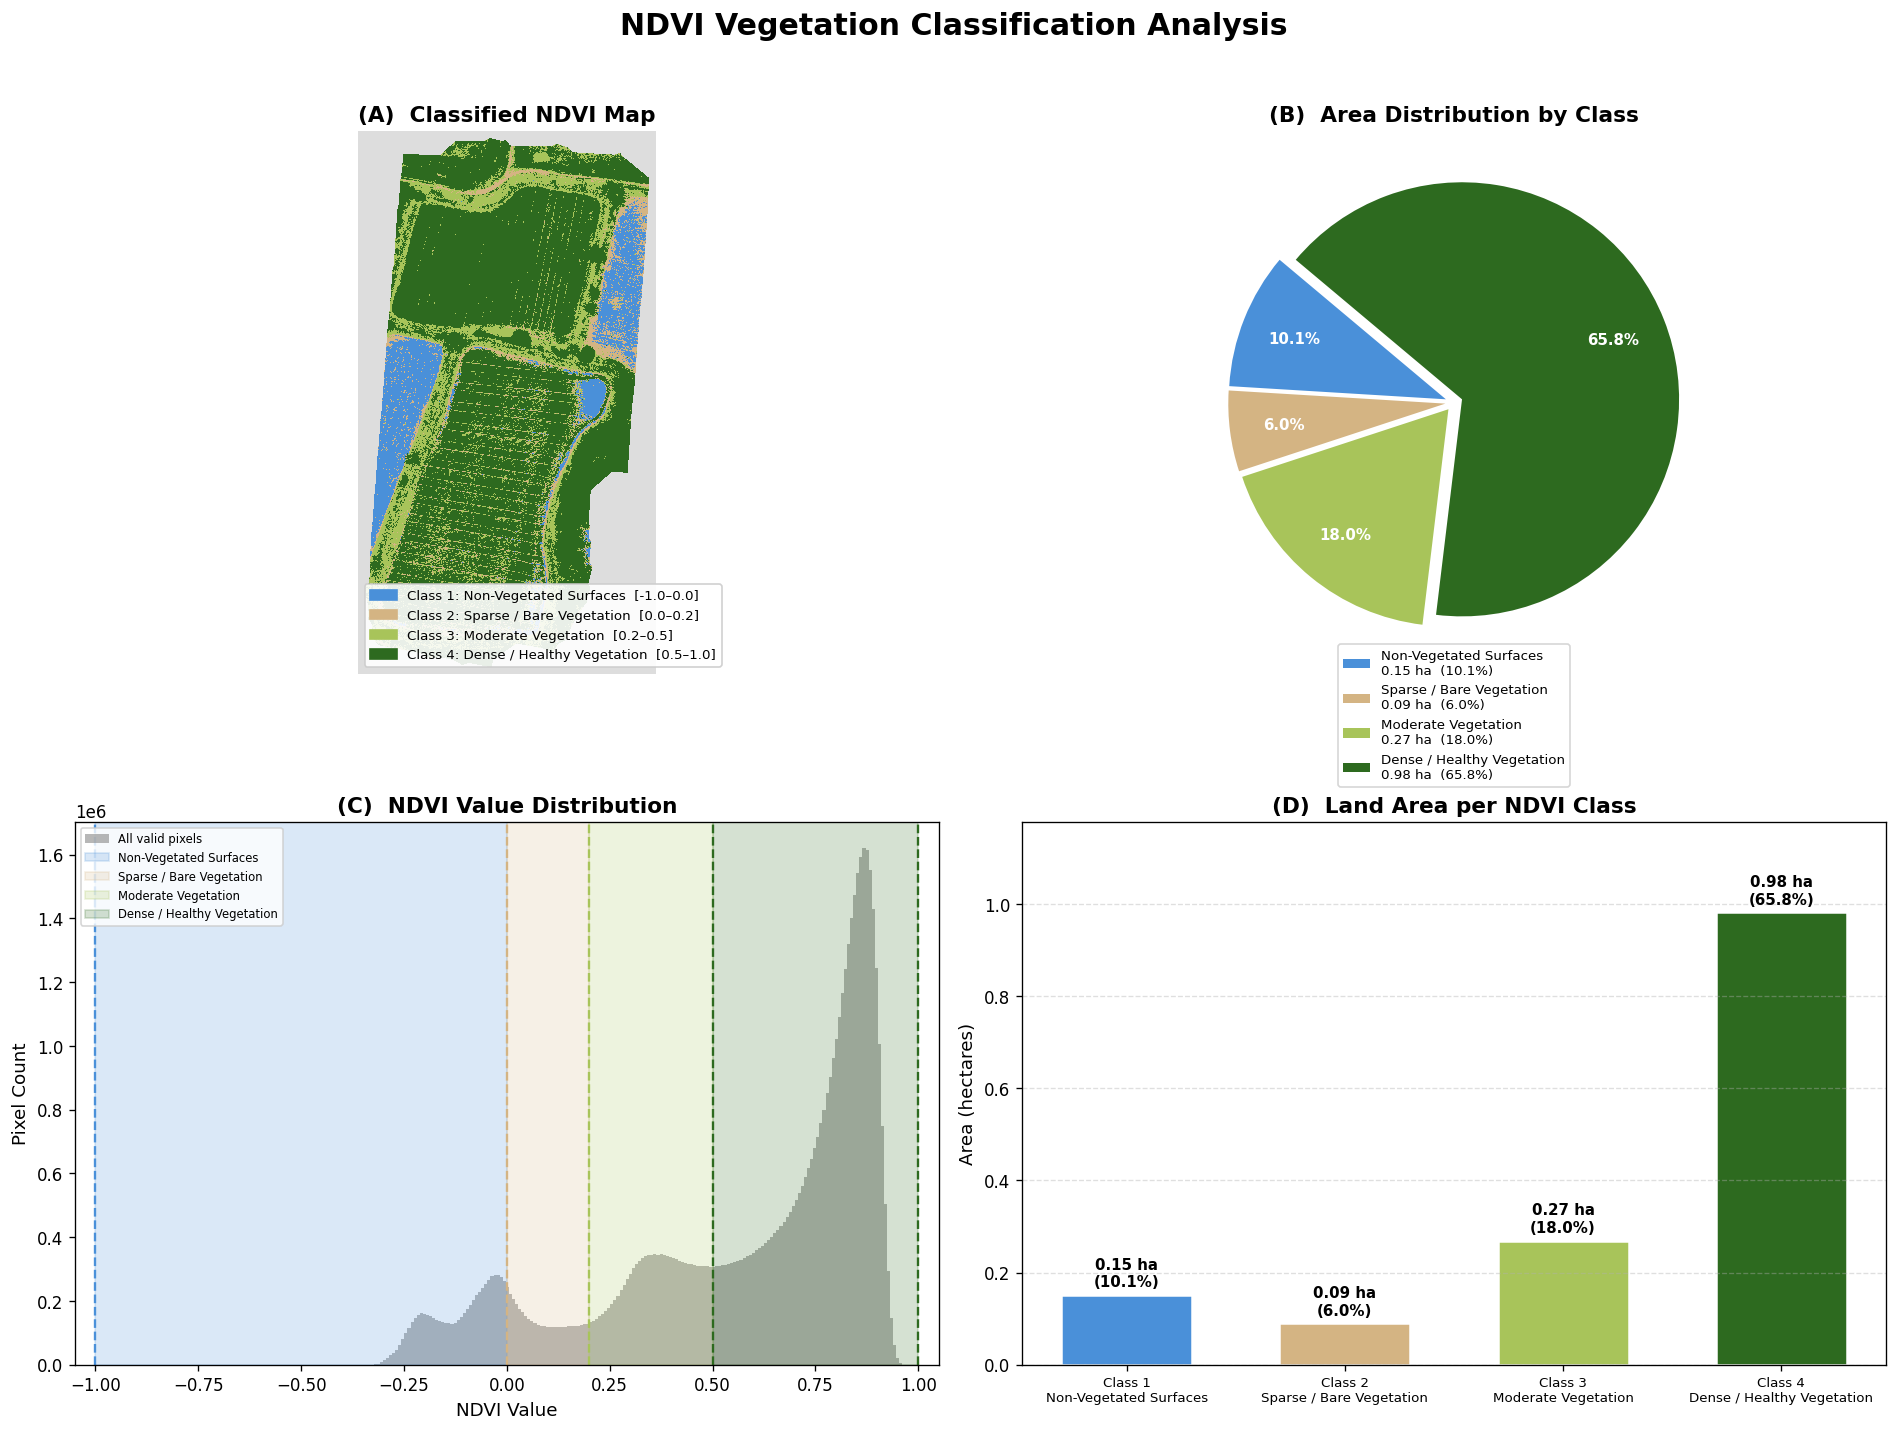

✅  Figure saved → ndvi_classification_report.png


In [ ]:
# ── 7.1  Build discrete colourmap for the classified map ─────────────────────
#
# class_map contains integer values 0–4:
#   0 → nodata (grey)
#   1–4 → NDVI classes (coloured as defined in NDVI_CLASSES)
#
# ListedColormap maps each integer value to a fixed colour.
# BoundaryNorm defines the integer bin edges [0, 1, 2, 3, 4, 5].

colors = [cls["color"] for cls in NDVI_CLASSES]  # list of 4 hex colour strings
labels = [cls["label"] for cls in NDVI_CLASSES]  # list of 4 class label strings

cmap = mcolors.ListedColormap(["#dddddd"] + colors)  # index 0 = nodata grey
norm = mcolors.BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

# ── 7.2  Create 2×2 figure layout ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "NDVI Vegetation Classification Analysis",
    fontsize=18, fontweight="bold", y=0.99
)

# ══ Panel A: Classified NDVI map ══════════════════════════════════════════════
ax = axes[0, 0]
ax.imshow(class_map, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title("(A)  Classified NDVI Map", fontsize=13, fontweight="bold")
ax.axis("off")

# Build legend patches manually (one coloured rectangle per class)
legend_patches = [
    mpatches.Patch(
        color=colors[i],
        label=f"Class {i+1}: {labels[i]}  [{NDVI_CLASSES[i]['min']:.1f}–{NDVI_CLASSES[i]['max']:.1f}]"
    )
    for i in range(len(NDVI_CLASSES))
]
ax.legend(handles=legend_patches, loc="lower left", fontsize=8, framealpha=0.9)

# ══ Panel B: Pie chart — proportional area distribution ═══════════════════════
ax = axes[0, 1]
pie_sizes   = stats["Percentage (%)"].values
pie_explode = [0.04] * len(NDVI_CLASSES)  # slight separation between all slices

wedges, _, autotexts = ax.pie(
    pie_sizes,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 1.5 else "",  # hide labels on tiny slices
    startangle=140,
    explode=pie_explode,
    pctdistance=0.75,
)
# Style inline percentage labels for readability on coloured backgrounds
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
    at.set_color("white")

ax.set_title("(B)  Area Distribution by Class", fontsize=13, fontweight="bold")
ax.legend(
    wedges,
    [f"{r['Label']}\n{r['Area (ha)']:.2f} ha  ({r['Percentage (%)']:.1f}%)"
     for _, r in stats.iterrows()],
    loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=1, fontsize=8
)

# ══ Panel C: NDVI histogram with shaded class regions ═════════════════════════
ax = axes[1, 0]
valid_vals = ndvi[~np.isnan(ndvi)].ravel()  # flatten to 1-D; exclude NaN

# Histogram of all valid NDVI values (200 bins covers the range well)
ax.hist(valid_vals, bins=200, color="#888888", edgecolor="none", alpha=0.6, label="All valid pixels")

# Overlay semi-transparent shading and dashed boundary lines for each class
for cls in NDVI_CLASSES:
    ax.axvspan(cls["min"], cls["max"], color=cls["color"], alpha=0.20, label=cls["label"])
    ax.axvline(cls["min"], color=cls["color"], linewidth=1.4, linestyle="--")
ax.axvline(NDVI_CLASSES[-1]["max"], color=NDVI_CLASSES[-1]["color"], linewidth=1.4, linestyle="--")

ax.set_xlabel("NDVI Value", fontsize=11)
ax.set_ylabel("Pixel Count", fontsize=11)
ax.set_title("(C)  NDVI Value Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=7, loc="upper left")
ax.set_xlim(-1.05, 1.05)

# ══ Panel D: Bar chart — land area (ha) per class ═════════════════════════════
ax = axes[1, 1]
area_ha_values = stats["Area (ha)"].values
bar_positions  = range(len(NDVI_CLASSES))

bars = ax.bar(
    bar_positions, area_ha_values,
    color=colors, edgecolor="white", linewidth=1.5, width=0.6
)
# Annotate each bar with area and percentage above the bar top
y_offset = max(area_ha_values) * 0.012  # dynamic vertical offset scales with data
for bar, ha_val, pct in zip(bars, area_ha_values, stats["Percentage (%)"].values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_offset,
        f"{ha_val:.2f} ha\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax.set_xticks(bar_positions)
ax.set_xticklabels(
    [f"Class {i+1}\n{cls['label']}" for i, cls in enumerate(NDVI_CLASSES)],
    fontsize=8
)
ax.set_ylabel("Area (hectares)", fontsize=11)
ax.set_title("(D)  Land Area per NDVI Class", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(area_ha_values) * 1.20)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ── 7.3  Save figure ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("ndvi_classification_report.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅  Figure saved → ndvi_classification_report.png")

---
## Section 8 — Export Outputs

All output files are saved to the Colab working directory (`/content/`) and then
downloaded to the local machine.

| # | File | Format | Description |
|---|------|--------|-------------|
| 1 | `NDVI_computed.tif` | GeoTIFF float32 | Computed NDVI raster (georeferenced) |
| 2 | `ndvi_classified.tif` | GeoTIFF uint8 | Classified map, class values 1–4 (georeferenced) |
| 3 | `ndvi_classification_stats.csv` | CSV | Per-class pixel count, percentage, area |
| 4 | `ndvi_healthy_area_summary.csv` | CSV | GSD and aggregated healthy area metrics |
| 5 | `ndvi_classification_report.png` | PNG 180 dpi | 4-panel figure |

In [ ]:
# ── 8.1  Save per-class statistics table as CSV ───────────────────────────────
stats.to_csv("ndvi_classification_stats.csv", index=False)
print("✅  Saved → ndvi_classification_stats.csv")

# ── 8.2  Save healthy area summary as CSV ────────────────────────────────────
pd.DataFrame([healthy_summary]).to_csv("ndvi_healthy_area_summary.csv", index=False)
print("✅  Saved → ndvi_healthy_area_summary.csv")

# ── 8.3  Save classified raster as georeferenced GeoTIFF ─────────────────────
#
# We update the metadata template (read from NIR in Section 3) to:
#   dtype  = uint8  — class values 1–4 fit comfortably in an unsigned byte
#   count  = 1      — single band
#   nodata = 0      — class 0 marks nodata pixels (matches class_map initialisation)

classified_out_meta = meta.copy()
classified_out_meta.update({"dtype": "uint8", "count": 1, "nodata": 0})

with rasterio.open("ndvi_classified.tif", "w", **classified_out_meta) as dst:
    dst.write(class_map[np.newaxis, :, :])  # add band dimension for rasterio write
print("✅  Saved → ndvi_classified.tif  (georeferenced, class values 1–4)")

# NDVI_computed.tif was already saved in Section 4 — no action needed here.
print("✅  ndvi_classification_report.png was saved in Section 7")

✅  Saved → ndvi_classification_stats.csv
✅  Saved → ndvi_healthy_area_summary.csv
✅  Saved → ndvi_classified.tif  (georeferenced, class values 1–4)
✅  ndvi_classification_report.png was saved in Section 7


In [ ]:
# ── 8.4  Download all output files to local machine ──────────────────────────
#
# files.download() triggers a browser download for each file.
# Run this cell only after all previous sections have completed successfully.

from google.colab import files

output_files = [
    "NDVI_computed.tif",
    "ndvi_classified.tif",
    "ndvi_classification_stats.csv",
    "ndvi_healthy_area_summary.csv",
    "ndvi_classification_report.png",
]

print("📥  Initiating downloads ...\n")
for fname in output_files:
    if os.path.exists(fname):
        files.download(fname)
        print(f"  ✅  {fname}")
    else:
        print(f"  ⚠️   {fname}  — not found; run earlier sections first")

📥  Initiating downloads ...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  NDVI_computed.tif


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅  ndvi_healthy_area_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  ndvi_classification_report.png


---
## Appendix — Interpretation Guide & References

### A.1  Reading your results

| Observation | Likely explanation |
|-------------|-------------------|
| Class 1 area unexpectedly large | Water bodies, roads, buildings, or deep shadow from the DSM |
| Class 2 area high | Field edges, access paths, recently tilled or replanted zones |
| Class 3 dominant | Crops not yet at peak canopy closure, or mixed grass/shrub land |
| Class 4 lower than expected | Drought stress, pest or disease damage, or nutrient deficiency |

### A.2  GSD and area calculation — assumptions and limitations

- GSD is derived from the affine transform, which encodes the output resolution
  of the orthomosaic processing pipeline (e.g. Pix4D, OpenDroneMap).
- Area estimates assume a **nadir sensor geometry over flat terrain**. On sloped
  ground the true surface area exceeds the planimetric area; a DEM-based
  slope correction would be required for high-accuracy terrain work.
- The WGS-84 degree-to-metre conversion used for geographic CRS files introduces
  an error of < 0.1% for latitudes below 60°.

### A.3  Cross-validation with companion spectral indices

| File | Index | Use alongside NDVI for |
|------|-------|------------------------|
| `NDRE.tif` | NDRE | Chlorophyll detection at high biomass where NDVI saturates |
| `LCI.tif` | LCI | Direct leaf chlorophyll content estimation |
| `OSAVI.tif` | OSAVI | Soil-adjusted comparison in Class 2 (sparse) areas |
| `segment.tif` | — | Field parcel boundaries — overlay for per-parcel statistics |

### A.4  References

- Tucker, C.J. (1979). Red and photographic infrared linear combinations for
  monitoring vegetation. *Remote Sensing of Environment*, 8(2), 127–150.
- Lillesand, T., Kiefer, R.W., & Chipman, J. (2015). *Remote Sensing and Image
  Interpretation* (7th ed.). Wiley.
- Gamon, J.A., Field, C.B., Goulden, M.L., et al. (1995). Relationships between
  NDVI, canopy structure, and photosynthesis in three Californian vegetation types.
  *Ecological Applications*, 5(1), 28–41.
- Huete, A., Didan, K., Miura, T., et al. (2002). Overview of the radiometric
  and biophysical performance of the MODIS vegetation indices. *Remote Sensing
  of Environment*, 83(1–2), 195–213.